In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader, Subset, ConcatDataset
from sklearn.model_selection import train_test_split
from torchvision import datasets, transforms



train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
)

test_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
)

print(train_dataset.data.shape)
print(test_dataset.data.shape)

torch.Size([60000, 28, 28])
torch.Size([10000, 28, 28])


In [17]:
# Tên các lớp
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

# Lấy label dưới dạng Python list / NumPy (không thao tác với tensor)
train_labels = np.array(train_dataset.targets.tolist())
test_labels = np.array(test_dataset.targets.tolist())

# Ghép tất cả label lại và đếm
all_labels = np.concatenate([train_labels, test_labels])
counts = np.bincount(all_labels, minlength=len(class_names))

print("\nSố lượng mẫu theo từng nhãn:")
for i, name in enumerate(class_names):
    print(f"{i} - {name}: {counts[i]} mẫu")


Số lượng mẫu theo từng nhãn:
0 - T-shirt/top: 7000 mẫu
1 - Trouser: 7000 mẫu
2 - Pullover: 7000 mẫu
3 - Dress: 7000 mẫu
4 - Coat: 7000 mẫu
5 - Sandal: 7000 mẫu
6 - Shirt: 7000 mẫu
7 - Sneaker: 7000 mẫu
8 - Bag: 7000 mẫu
9 - Ankle boot: 7000 mẫu


In [18]:
full_dataset = ConcatDataset([train_dataset, test_dataset])

all_labels = np.concatenate([
    train_dataset.targets.numpy(),
    test_dataset.targets.numpy()
])

indices = np.arange(len(full_dataset))

# 60% train
train_idx, temp_idx = train_test_split(
    indices,
    test_size=0.4,
    stratify=all_labels,
    random_state=42
)

# 20% val + 20% test
temp_labels = all_labels[temp_idx]

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.5,
    stratify=temp_labels,
    random_state=42
)

train_dataset = Subset(full_dataset, train_idx)
val_dataset = Subset(full_dataset, val_idx)
test_dataset = Subset(full_dataset, test_idx)

print(f"Train: {len(train_dataset)}")
print(f"Val:   {len(val_dataset)}")
print(f"Test:  {len(test_dataset)}")

for name, idx in [
    ("Train", train_idx),
    ("Val", val_idx),
    ("Test", test_idx)
]:
    labels = all_labels[idx]
    counts = np.bincount(labels)

    print(f"\n{name}")
    for i in range(10):
        print(f"{class_names[i]:12s}: {counts[i]}")

Train: 42000
Val:   14000
Test:  14000

Train
T-shirt/top : 4200
Trouser     : 4200
Pullover    : 4200
Dress       : 4200
Coat        : 4200
Sandal      : 4200
Shirt       : 4200
Sneaker     : 4200
Bag         : 4200
Ankle boot  : 4200

Val
T-shirt/top : 1400
Trouser     : 1400
Pullover    : 1400
Dress       : 1400
Coat        : 1400
Sandal      : 1400
Shirt       : 1400
Sneaker     : 1400
Bag         : 1400
Ankle boot  : 1400

Test
T-shirt/top : 1400
Trouser     : 1400
Pullover    : 1400
Dress       : 1400
Coat        : 1400
Sandal      : 1400
Shirt       : 1400
Sneaker     : 1400
Bag         : 1400
Ankle boot  : 1400


In [19]:
import torch
from torchvision import transforms

# Wrapper để áp transform lên Subset mà không sửa dataset gốc
class TransformedSubset(torch.utils.data.Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
    def __len__(self):
        return len(self.subset)
    def __getitem__(self, idx):
        img, label = self.subset[idx]   # trả về PIL image, label
        if self.transform:
            img = self.transform(img)   # trở thành tensor
        return img, label

# Tính toán mean và std siêu tốc bằng vectorization trên CPU
raw_data_list = []
for idx in train_dataset.indices:
    if idx < 60000:
        img = full_dataset.datasets[0].data[idx]
    else:
        img = full_dataset.datasets[1].data[idx - 60000]
    raw_data_list.append(img if isinstance(img, torch.Tensor) else torch.tensor(img))
train_imgs = torch.stack(raw_data_list).float() / 255.0
mean = [train_imgs.mean().item()]
std = [train_imgs.std().item()]

print("mean:", mean)
print("std: ", std)

mean: [0.2858455181121826]
std:  [0.3527945578098297]


In [20]:
train_transform = transforms.Compose([
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.ToTensor()
])

# Thêm định nghĩa GPUTransforms lớp tối ưu hóa ở đây
import torch.nn as nn

class GPUTransforms(nn.Module):
    def __init__(self, mean, std, training=True, augmentations=None):
        super().__init__()
        self.training = training
        self.mean = torch.tensor(mean)
        self.std = torch.tensor(std)
        self.augmentations = augmentations
        
    def forward(self, x):
        # x shape: [B, 1, 28, 28] on device
        if self.training and self.augmentations is not None:
            x = self.augmentations(x)
        # Resize lên 224x224
        x = nn.functional.interpolate(x, size=(224, 224), mode='bilinear', align_corners=False)
        # Chuyển thành 3 kênh bằng cách lặp lại kênh xám
        x = x.repeat(1, 3, 1, 1)
        # Chuẩn hóa
        mean = self.mean.to(x.device).view(1, -1, 1, 1)
        std = self.std.to(x.device).view(1, -1, 1, 1)
        x = (x - mean) / std
        return x

# Khởi tạo GPU transforms đơn giản ban đầu
gpu_train_transform = GPUTransforms(mean, std, training=True, augmentations=transforms.RandomRotation(10))
gpu_test_transform = GPUTransforms(mean, std, training=False)

In [21]:
# Tạo transformed subsets
train_ds = TransformedSubset(train_dataset, transform=train_transform)
val_ds   = TransformedSubset(val_dataset, transform=test_transform)
test_ds  = TransformedSubset(test_dataset, transform=test_transform)

# DataLoaders (Tối ưu hóa batch_size=256 và num_workers=0 trên Windows)
batch_size = 256
num_workers = 0
pin_memory = True
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=num_workers, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)

In [22]:
import timm

model = timm.create_model(
    'deit_tiny_patch16_224',
    pretrained=True,
    num_classes=10
)

In [23]:
print(model)

VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 192, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=192, out_features=576, bias=True)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=192, out_features=192, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (drop_path): Identity()
      (norm2): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=192, out_features=768, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False)
        (fc2): Linear(in_features=768, out_features=192, bias=True)
        (drop2): Dropout(p=0.0, inplace=False)
      )
    )
    (1): Block(
      (norm1): La

In [24]:
for name, module in model.named_modules():
    print(name, "->", module)

 -> VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 192, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=192, out_features=576, bias=True)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=192, out_features=192, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (drop_path): Identity()
      (norm2): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=192, out_features=768, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False)
        (fc2): Linear(in_features=768, out_features=192, bias=True)
        (drop2): Dropout(p=0.0, inplace=False)
      )
    )
    (1): Block(
      (norm1)

In [25]:
total_params = sum(p.numel() for p in model.parameters())
print(f"{total_params:,}")

5,526,346


In [26]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)
print("Using device:", device)
model = model.to(device)

Using device: cuda


In [27]:
import torch
import torch.nn as nn
import torch.optim as optim
from peft import LoraConfig, get_peft_model

# 1. Khởi tạo cấu hình LoRA (Đã sửa target_modules thành "qkv" cho mô hình DeiT)
lora_config = LoraConfig(
    r=8,                                # Hạng của ma trận (Rank r)
    lora_alpha=16,                      # Hệ số scaling
    target_modules=["qkv"],             # Tiêm LoRA thẳng vào layer gộp qkv của DeiT
    lora_dropout=0.05,                  # Tỷ lệ dropout cho các nhánh LoRA
    bias="none"
)

# 2. Bọc mô hình DeiT gốc bằng cấu hình LoRA (Đóng băng xương sống gốc)
model = get_peft_model(model, lora_config)

# 3. Mở khóa lớp phân loại cuối cùng (Classifier Head) để thích ứng với 10 lớp mới
for param in model.base_model.model.head.parameters():
    param.requires_grad = True

# 4. In kiểm tra số lượng tham số để cập nhật số liệu lên Slide
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print(f"Trainable parameters (LoRA + Head): {trainable_params:,}")
print(f"Total parameters: {total_params:,}")
print(f"Percentage of trainable parameters: {100 * trainable_params / total_params:.3f}%")

# 5. KHAI BÁO HÀM LOSS (CRITERION) - Đã bổ sung đầy đủ
criterion = nn.CrossEntropyLoss()

# 6. Khởi tạo Optimizer (Nhận diện các tham số LoRA + Head dựa trên requires_grad)
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)

# 7. Cấu hình lại Bộ giảm tốc độ học (Learning Rate Scheduler)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.1,
    patience=3,

)

Trainable parameters (LoRA + Head): 75,658
Total parameters: 5,600,074
Percentage of trainable parameters: 1.351%


In [28]:
def train_epoch(model, dataloader, criterion, optimizer, device, gpu_transform, scaler):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device, non_blocking=True)
        images = gpu_transform(images)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * images.size(0)

        _, predicted = outputs.max(1)

        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [29]:
@torch.no_grad()
def evaluate(model, dataloader, criterion, device, gpu_transform):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device, non_blocking=True)
        images = gpu_transform(images)
        labels = labels.to(device, non_blocking=True)

        with torch.cuda.amp.autocast():
            outputs = model(images)
            loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)

        _, predicted = outputs.max(1)

        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [32]:
import copy

best_model_weights = None
num_epochs = 20
best_val_loss = float("inf")
best_epoch = 0
early_stop_counter = 0
patience = 5

# Khởi tạo scaler cho AMP
scaler = torch.amp.GradScaler('cuda')

for epoch in range(num_epochs):

    train_loss, train_acc = train_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device,
        gpu_train_transform,
        scaler
    )

    val_loss, val_acc = evaluate(
        model,
        val_loader,
        criterion,
        device,
        gpu_test_transform
    )

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

    if val_loss < best_val_loss:

        best_val_loss = val_loss
        best_epoch = epoch + 1
        early_stop_counter = 0

        best_model_weights = copy.deepcopy(
            model.state_dict()
        )

        print(
            f"Best model updated "
            f"(epoch {best_epoch})"
        )

    else:

        early_stop_counter += 1

        print(
            f"No improvement "
            f"({early_stop_counter}/{patience})"
        )

    if early_stop_counter >= patience:

        print(
            f"Early stopping at epoch {epoch+1}"
        )

        break

model.load_state_dict(best_model_weights)

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_21500\3915616969.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_21500\771368122.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 1/20 | Train Loss: 0.1727 | Train Acc: 0.9364 | Val Loss: 0.1977 | Val Acc: 0.9305
Best model updated (epoch 1)
Epoch 2/20 | Train Loss: 0.1583 | Train Acc: 0.9430 | Val Loss: 0.1885 | Val Acc: 0.9326
Best model updated (epoch 2)
Epoch 3/20 | Train Loss: 0.1547 | Train Acc: 0.9446 | Val Loss: 0.2019 | Val Acc: 0.9294
No improvement (1/5)
Epoch 4/20 | Train Loss: 0.1475 | Train Acc: 0.9462 | Val Loss: 0.1974 | Val Acc: 0.9326
No improvement (2/5)
Epoch 5/20 | Train Loss: 0.1434 | Train Acc: 0.9464 | Val Loss: 0.1994 | Val Acc: 0.9331
No improvement (3/5)
Epoch 6/20 | Train Loss: 0.1429 | Train Acc: 0.9481 | Val Loss: 0.1956 | Val Acc: 0.9331
No improvement (4/5)
Epoch 7/20 | Train Loss: 0.1333 | Train Acc: 0.9506 | Val Loss: 0.1996 | Val Acc: 0.9321
No improvement (5/5)
Early stopping at epoch 7


<All keys matched successfully>

In [33]:
model.load_state_dict(best_model_weights)

<All keys matched successfully>

In [ ]:
%%sql


In [36]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)
from sklearn.preprocessing import label_binarize


def evaluate_model(model, dataloader, device, num_classes, class_names=None, gpu_transform=None):

    model.eval()

    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            if gpu_transform is not None:
                images = gpu_transform(images)
            labels = labels.to(device)

            with torch.cuda.amp.autocast():
                outputs = model(images)              # logits
                probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_labels.append(labels.cpu())
            all_preds.append(preds.cpu())
            all_probs.append(probs.cpu())

    y_true = torch.cat(all_labels).numpy()
    y_pred = torch.cat(all_preds).numpy()
    y_prob = torch.cat(all_probs).numpy()

    # =========================
    # ACCURACY
    # =========================
    acc = accuracy_score(y_true, y_pred)

    # =========================
    # PER-CLASS METRICS
    # =========================
    precision_cls = precision_score(y_true, y_pred, average=None, zero_division=0)
    recall_cls = recall_score(y_true, y_pred, average=None, zero_division=0)
    f1_cls = f1_score(y_true, y_pred, average=None, zero_division=0)

    # =========================
    # SUMMARY METRICS
    # =========================
    precision_macro = precision_score(y_true, y_pred, average="macro", zero_division=0)
    recall_macro = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)

    precision_weighted = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    recall_weighted = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1_weighted = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    # =========================
    # AUC (MULTI-CLASS OVR)
    # =========================
    y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))

    auc = roc_auc_score(
        y_true_bin,
        y_prob,
        multi_class="ovr",
        average="macro"
    )

    # =========================
    # CONFUSION MATRIX
    # =========================
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names if class_names else range(num_classes),
        yticklabels=class_names if class_names else range(num_classes)
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.show()

    # =========================
    # PRINT RESULTS
    # =========================
    print("\n================ VALIDATION RESULT ================\n")

    print(f"Accuracy: {acc:.4f}")
    print(f"AUC     : {auc:.4f}")

    print("\n---- Macro ----")
    print(f"Precision: {precision_macro:.4f}")
    print(f"Recall   : {recall_macro:.4f}")
    print(f"F1-score : {f1_macro:.4f}")

    print("\n---- Weighted ----")
    print(f"Precision: {precision_weighted:.4f}")
    print(f"Recall   : {recall_weighted:.4f}")
    print(f"F1-score : {f1_weighted:.4f}")

    print("\n---- Per-class ----")
    if class_names is None:
        class_names = [f"class_{i}" for i in range(num_classes)]

    for i in range(num_classes):
        print(f"{class_names[i]:15s} | "
              f"P: {precision_cls[i]:.4f} | "
              f"R: {recall_cls[i]:.4f} | "
              f"F1: {f1_cls[i]:.4f}")

    return {
        "acc": acc,
        "auc": auc,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro
    }

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_21500\3160914198.py:32: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


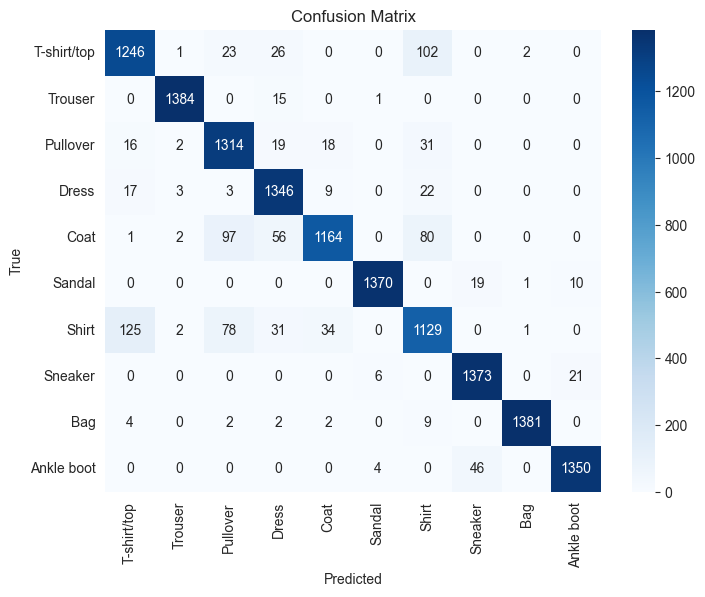


================ VALIDATION RESULT ================

Accuracy: 0.9326
AUC     : 0.9968

---- Macro ----
Precision: 0.9336
Recall   : 0.9326
F1-score : 0.9325

---- Weighted ----
Precision: 0.9336
Recall   : 0.9326
F1-score : 0.9325

---- Per-class ----
T-shirt/top     | P: 0.8843 | R: 0.8900 | F1: 0.8871
Trouser         | P: 0.9928 | R: 0.9886 | F1: 0.9907
Pullover        | P: 0.8662 | R: 0.9386 | F1: 0.9009
Dress           | P: 0.9003 | R: 0.9614 | F1: 0.9299
Coat            | P: 0.9487 | R: 0.8314 | F1: 0.8862
Sandal          | P: 0.9920 | R: 0.9786 | F1: 0.9853
Shirt           | P: 0.8223 | R: 0.8064 | F1: 0.8143
Sneaker         | P: 0.9548 | R: 0.9807 | F1: 0.9676
Bag             | P: 0.9971 | R: 0.9864 | F1: 0.9917
Ankle boot      | P: 0.9776 | R: 0.9643 | F1: 0.9709


In [37]:
metrics = evaluate_model(
    model,
    val_loader,
    device,
    num_classes=10,
    class_names=class_names,
    gpu_transform=gpu_test_transform
)